In [1]:
from sklearn.datasets import fetch_20newsgroups
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import NMF
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.decomposition import KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

In [2]:
data = fetch_20newsgroups(subset='all')

In [3]:
df = pd.DataFrame(data.data)

In [4]:
df

,0
0,From: Mamatha Devineni Ratnam <mr47+@andrew.cm...
1,From: mblawson@midway.ecn.uoknor.edu (Matthew ...
2,From: hilmi-er@dsv.su.se (Hilmi Eren)\nSubject...
3,From: guyd@austin.ibm.com (Guy Dawson)\nSubjec...
4,From: Alexander Samuel McDiarmid <am2o+@andrew...
...,...
18841,From: jim.zisfein@factory.com (Jim Zisfein) \n...
18842,From: rdell@cbnewsf.cb.att.com (richard.b.dell...
18843,From: westes@netcom.com (Will Estes)\nSubject:...
18844,From: steve@hcrlgw (Steven Collins)\nSubject: ...


In [5]:
# Proper DataFrame with both text and label
df = pd.DataFrame({
    'text': data.data,
    'label': data.target,
    'category': [data.target_names[i] for i in data.target]
})

In [6]:
df

,text,label,category
0,From: Mamatha Devineni Ratnam <mr47+@andrew.cm...,10,rec.sport.hockey
1,From: mblawson@midway.ecn.uoknor.edu (Matthew ...,3,comp.sys.ibm.pc.hardware
2,From: hilmi-er@dsv.su.se (Hilmi Eren)\nSubject...,17,talk.politics.mideast
3,From: guyd@austin.ibm.com (Guy Dawson)\nSubjec...,3,comp.sys.ibm.pc.hardware
4,From: Alexander Samuel McDiarmid <am2o+@andrew...,4,comp.sys.mac.hardware
...,...,...,...
18841,From: jim.zisfein@factory.com (Jim Zisfein) \n...,13,sci.med
18842,From: rdell@cbnewsf.cb.att.com (richard.b.dell...,12,sci.electronics
18843,From: westes@netcom.com (Will Estes)\nSubject:...,3,comp.sys.ibm.pc.hardware
18844,From: steve@hcrlgw (Steven Collins)\nSubject: ...,1,comp.graphics


In [7]:
df['category'].unique()

array(['rec.sport.hockey', 'comp.sys.ibm.pc.hardware',
       'talk.politics.mideast', 'comp.sys.mac.hardware',
       'sci.electronics', 'talk.religion.misc', 'sci.crypt', 'sci.med',
       'alt.atheism', 'rec.motorcycles', 'rec.autos', 'comp.windows.x',
       'comp.graphics', 'sci.space', 'talk.politics.guns', 'misc.forsale',
       'rec.sport.baseball', 'talk.politics.misc',
       'comp.os.ms-windows.misc', 'soc.religion.christian'], dtype=object)

In [8]:
df['category'].value_counts()

category
rec.sport.hockey            999
soc.religion.christian      997
rec.motorcycles             996
rec.sport.baseball          994
sci.crypt                   991
rec.autos                   990
sci.med                     990
comp.windows.x              988
sci.space                   987
comp.os.ms-windows.misc     985
sci.electronics             984
comp.sys.ibm.pc.hardware    982
misc.forsale                975
comp.graphics               973
comp.sys.mac.hardware       963
talk.politics.mideast       940
talk.politics.guns          910
alt.atheism                 799
talk.politics.misc          775
talk.religion.misc          628
Name: count, dtype: int64

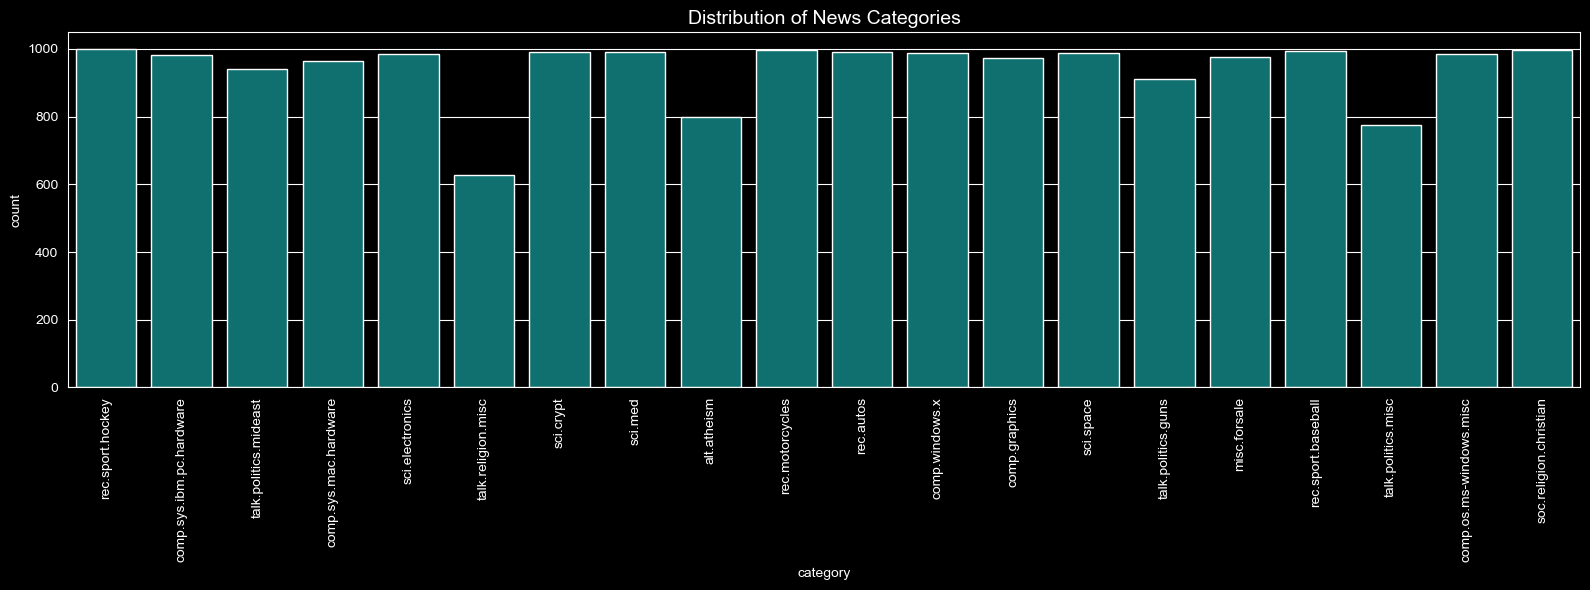

In [9]:
plt.figure(figsize=(16, 6))
sns.countplot(x='category', data=df, color='teal')
plt.title("Distribution of News Categories", fontsize=14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [10]:
def clean_text(text):
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()
    return text

In [11]:
df["cleaned_text"] = df["text"].apply(lambda x: clean_text(x))

In [12]:
df

,text,label,category,cleaned_text
0,From: Mamatha Devineni Ratnam <mr47+@andrew.cm...,10,rec.sport.hockey,from mamatha devineni ratnam subject pens fans...
1,From: mblawson@midway.ecn.uoknor.edu (Matthew ...,3,comp.sys.ibm.pc.hardware,from matthew b lawson subject which highperfor...
2,From: hilmi-er@dsv.su.se (Hilmi Eren)\nSubject...,17,talk.politics.mideast,from hilmi eren subject re armenia says it cou...
3,From: guyd@austin.ibm.com (Guy Dawson)\nSubjec...,3,comp.sys.ibm.pc.hardware,from guy dawson subject re ide vs scsi dma and...
4,From: Alexander Samuel McDiarmid <am2o+@andrew...,4,comp.sys.mac.hardware,from alexander samuel mcdiarmid subject driver...
...,...,...,...,...
18841,From: jim.zisfein@factory.com (Jim Zisfein) \n...,13,sci.med,from jim zisfein subject re migraines and scan...
18842,From: rdell@cbnewsf.cb.att.com (richard.b.dell...,12,sci.electronics,from richardbdell subject re a question about ...
18843,From: westes@netcom.com (Will Estes)\nSubject:...,3,comp.sys.ibm.pc.hardware,from will estes subject mounting cpu cooler in...
18844,From: steve@hcrlgw (Steven Collins)\nSubject: ...,1,comp.graphics,from steven collins subject re sphere from poi...


In [13]:
df.drop(columns=["text"], inplace=True)

In [14]:
df

,label,category,cleaned_text
0,10,rec.sport.hockey,from mamatha devineni ratnam subject pens fans...
1,3,comp.sys.ibm.pc.hardware,from matthew b lawson subject which highperfor...
2,17,talk.politics.mideast,from hilmi eren subject re armenia says it cou...
3,3,comp.sys.ibm.pc.hardware,from guy dawson subject re ide vs scsi dma and...
4,4,comp.sys.mac.hardware,from alexander samuel mcdiarmid subject driver...
...,...,...,...
18841,13,sci.med,from jim zisfein subject re migraines and scan...
18842,12,sci.electronics,from richardbdell subject re a question about ...
18843,3,comp.sys.ibm.pc.hardware,from will estes subject mounting cpu cooler in...
18844,1,comp.graphics,from steven collins subject re sphere from poi...


In [15]:
tfidf = TfidfVectorizer(
    max_features=5000,   # keep top 5000 words only
    stop_words='english', # remove common words (the, is, a)
    min_df=5,            # word must appear in at least 5 docs
    max_df=0.95          # ignore words appearing in 95%+ docs
)

In [16]:
df['label'].values

array([10,  3, 17, ...,  3,  1,  7])

In [17]:
X = tfidf.fit_transform(df['cleaned_text'])
y = df['label'].values

In [18]:
print("TF-IDF Matrix Shape:", X.shape)
print("Sparse matrix type:", type(X))
print()
print("Total articles:", X.shape[0])
print("Total features (words):", X.shape[1])

TF-IDF Matrix Shape: (18846, 5000)
Sparse matrix type: <class 'scipy.sparse._csr.csr_matrix'>

Total articles: 18846
Total features (words): 5000


In [19]:
tsvd = TruncatedSVD(n_components=100,random_state=42)
X_tsvd = tsvd.fit_transform(X)

In [20]:
print("Original shape:", X.shape)
print("After TSVD shape:", X_tsvd.shape)
print()
print("Variance retained by each component (first 10):")
print(tsvd.explained_variance_ratio_[:10].round(3))
print()
print("Total variance retained:",
      round(tsvd.explained_variance_ratio_.sum() * 100, 2), "%")

Original shape: (18846, 5000)
After TSVD shape: (18846, 100)

Variance retained by each component (first 10):
[0.002 0.006 0.004 0.004 0.003 0.003 0.003 0.003 0.003 0.002]

Total variance retained: 15.56 %


In [21]:
tsvd = TruncatedSVD(n_components=300, random_state=42)
X_tsvd = tsvd.fit_transform(X)

print("Original shape:", X.shape)
print("After TSVD shape:", X_tsvd.shape)
print("Total variance retained:",
      round(tsvd.explained_variance_ratio_.sum() * 100, 2), "%")

Original shape: (18846, 5000)
After TSVD shape: (18846, 300)
Total variance retained: 30.88 %


In [22]:
# NMF needs non-negative values — TF-IDF is already non-negative
nmf = NMF(n_components=20, random_state=42, max_iter=400)
X_nmf = nmf.fit_transform(X)

In [23]:
# Print top 10 words for each discovered topic
feature_names = tfidf.get_feature_names_out()

In [24]:
print("=== DISCOVERED TOPICS ===\n")
for topic_idx, topic in enumerate(nmf.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-10:][::-1]]
    print(f"Topic {topic_idx + 1:2d}: {' | '.join(top_words)}")

=== DISCOVERED TOPICS ===

Topic  1: god | jesus | bible | christian | faith | christians | christ | gods | believe | sin
Topic  2: thanks | email | help | know | looking | advance | university | info | information | im
Topic  3: game | team | games | hockey | players | year | baseball | espn | play | season
Topic  4: key | clipper | chip | encryption | keys | government | escrow | algorithm | security | crypto
Topic  5: drive | scsi | ide | drives | hard | disk | controller | mb | floppy | mac
Topic  6: windows | dos | os | nt | microsoft | run | win | memory | ms | running
Topic  7: people | dont | think | just | like | gun | right | government | know | im
Topic  8: article | writes | university | nntppostinghost | distribution | usa | john | michael | replyto | world
Topic  9: card | video | monitor | drivers | mhz | dx | vga | bit | cards | bus
Topic 10: car | cars | engine | dealer | ford | oil | insurance | good | speed | price
Topic 11: armenian | armenians | turkish | serdar | 

In [25]:
# Select 6 most distinct categories for cleaner visualization
selected_categories = [
    'sci.space',
    'rec.sport.hockey',
    'talk.religion.misc',
    'comp.graphics',
    'rec.autos',
    'sci.med'
]

# Filter dataframe for selected categories
mask = df['category'].isin(selected_categories)
df_subset = df[mask].reset_index(drop=True)

# Get corresponding TF-IDF rows
X_subset = X[mask.values]
y_subset = df_subset['label'].values

print("Subset shape:", X_subset.shape)
print("Categories selected:", df_subset['category'].value_counts().to_dict())


Subset shape: (5567, 5000)
Categories selected: {'rec.sport.hockey': 999, 'sci.med': 990, 'rec.autos': 990, 'sci.space': 987, 'comp.graphics': 973, 'talk.religion.misc': 628}


Variance explained by component 1: 0.87 %
Variance explained by component 2: 0.71 %
Total variance retained: 1.58 %


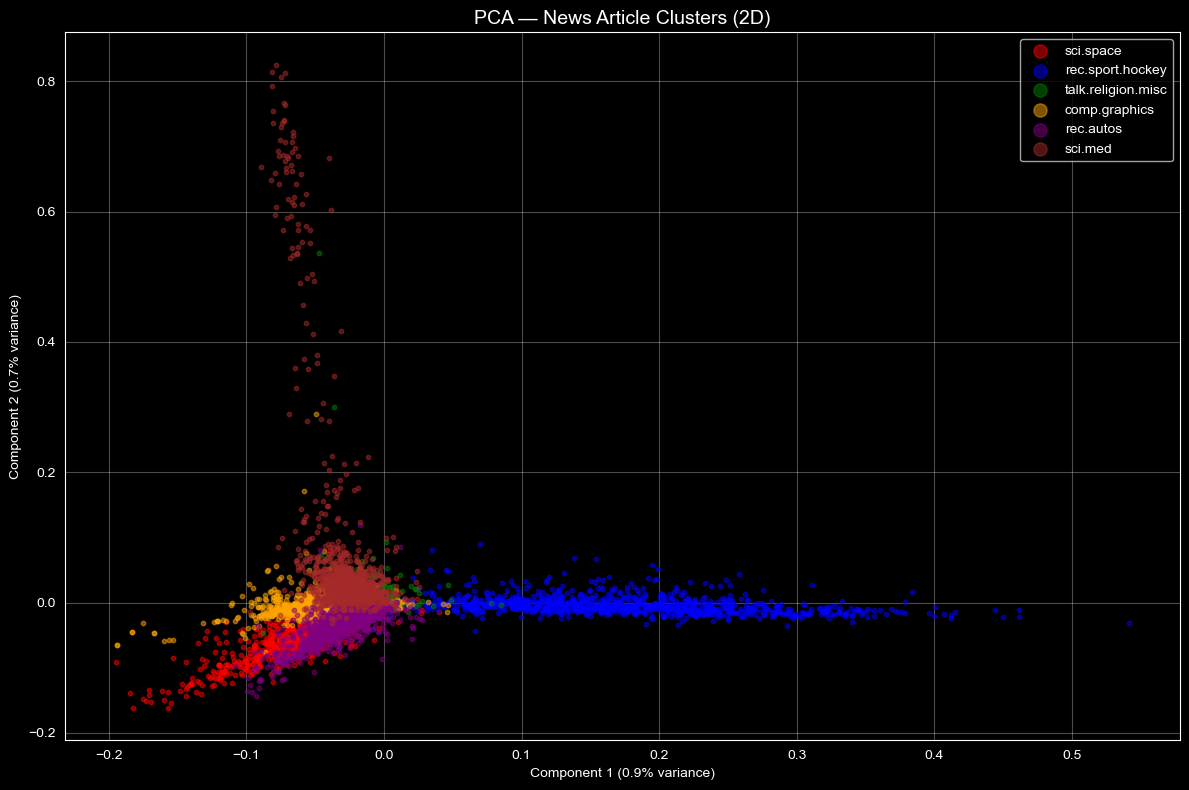

In [26]:
# Step 1: Apply PCA - reduce to 2 components for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_subset.toarray())

print("Variance explained by component 1:",
      round(pca.explained_variance_ratio_[0] * 100, 2), "%")
print("Variance explained by component 2:",
      round(pca.explained_variance_ratio_[1] * 100, 2), "%")
print("Total variance retained:",
      round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

# Step 2: Plot
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

plt.figure(figsize=(12, 8))

for i, category in enumerate(selected_categories):
    mask_cat = df_subset['category'] == category
    plt.scatter(
        X_pca[mask_cat, 0],
        X_pca[mask_cat, 1],
        c=colors[i],
        label=category,
        alpha=0.5,
        s=10
    )

plt.title("PCA — News Article Clusters (2D)", fontsize=14)
plt.xlabel(f"Component 1 ({round(pca.explained_variance_ratio_[0]*100,1)}% variance)")
plt.ylabel(f"Component 2 ({round(pca.explained_variance_ratio_[1]*100,1)}% variance)")
plt.legend(markerscale=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Variance retained by TSVD: 22.31 %
Variance retained by PCA on top: 7.06 %


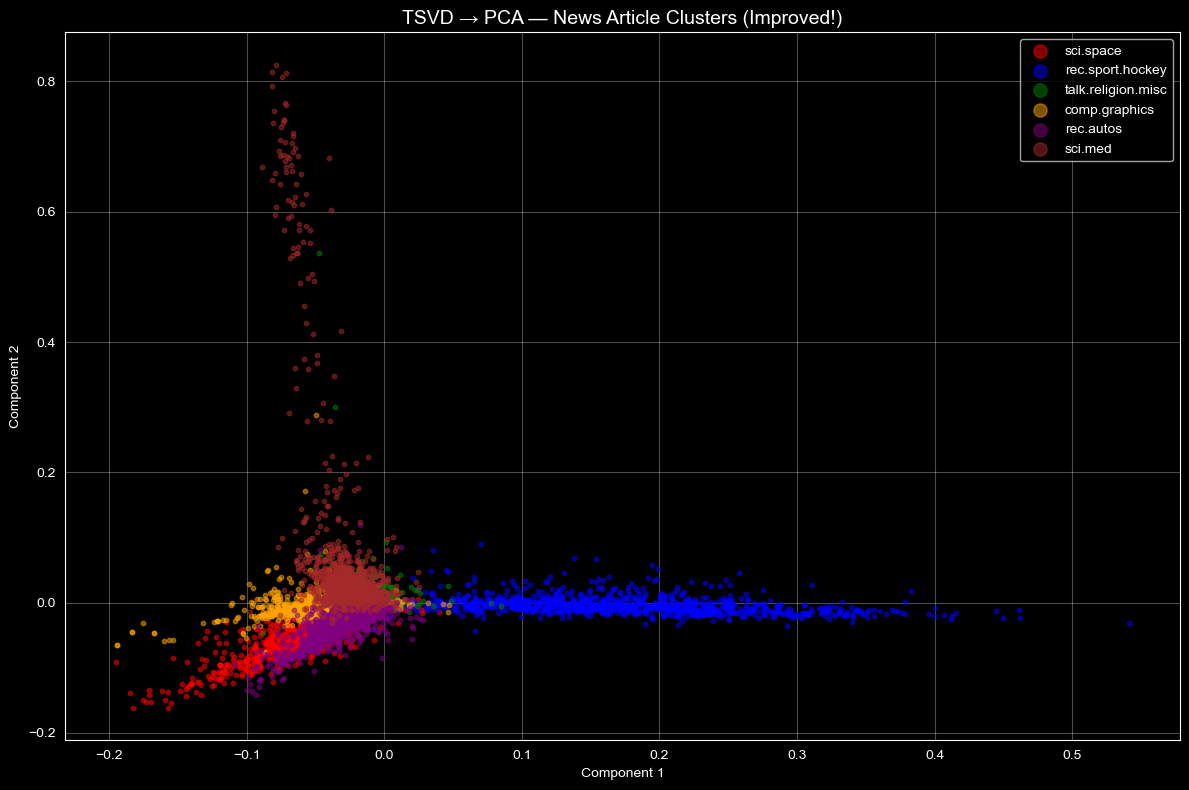

In [27]:
# Better approach: TSVD first → then PCA for visualization

# Step 1: TSVD on sparse matrix (text friendly!)
tsvd_viz = TruncatedSVD(n_components=100, random_state=42)
X_tsvd_subset = tsvd_viz.fit_transform(X_subset)

# Step 2: PCA on dense TSVD output (now only 100 features!)
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_tsvd_subset)

print("Variance retained by TSVD:",
      round(tsvd_viz.explained_variance_ratio_.sum() * 100, 2), "%")
print("Variance retained by PCA on top:",
      round(pca2.explained_variance_ratio_.sum() * 100, 2), "%")

# Plot
plt.figure(figsize=(12, 8))

for i, category in enumerate(selected_categories):
    mask_cat = df_subset['category'] == category
    plt.scatter(
        X_pca2[mask_cat, 0],
        X_pca2[mask_cat, 1],
        c=colors[i],
        label=category,
        alpha=0.5,
        s=10
    )

plt.title("TSVD → PCA — News Article Clusters (Improved!)", fontsize=14)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(markerscale=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

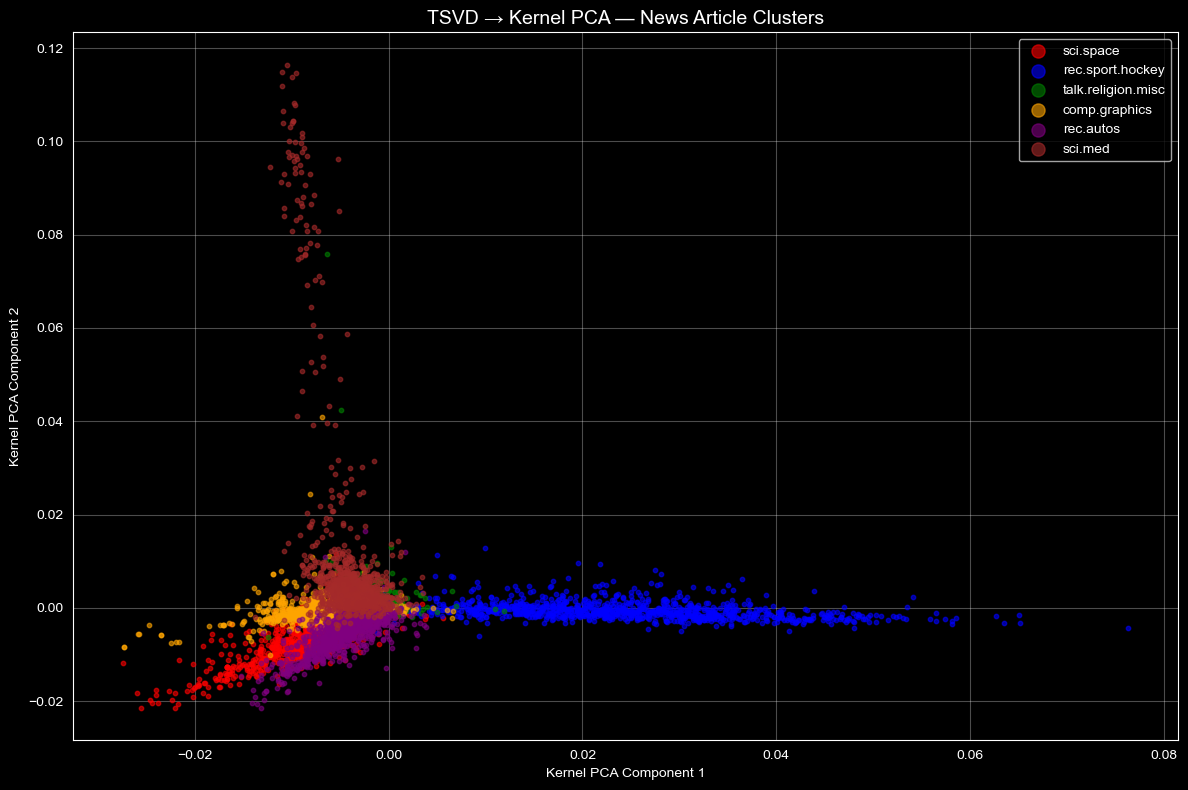

In [28]:
# Kernel PCA on TSVD output
kpca = KernelPCA(
    n_components=2,
    kernel='rbf',      # RBF kernel for non-linear!
    gamma=0.01,        # kernel coefficient
    random_state=42
)

X_kpca = kpca.fit_transform(X_tsvd_subset)

# Plot
plt.figure(figsize=(12, 8))

for i, category in enumerate(selected_categories):
    mask_cat = df_subset['category'] == category
    plt.scatter(
        X_kpca[mask_cat, 0],
        X_kpca[mask_cat, 1],
        c=colors[i],
        label=category,
        alpha=0.6,
        s=10
    )

plt.title("TSVD → Kernel PCA — News Article Clusters", fontsize=14)
plt.xlabel("Kernel PCA Component 1")
plt.ylabel("Kernel PCA Component 2")
plt.legend(markerscale=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Running t-SNE... please wait ⏳
Done! ✅


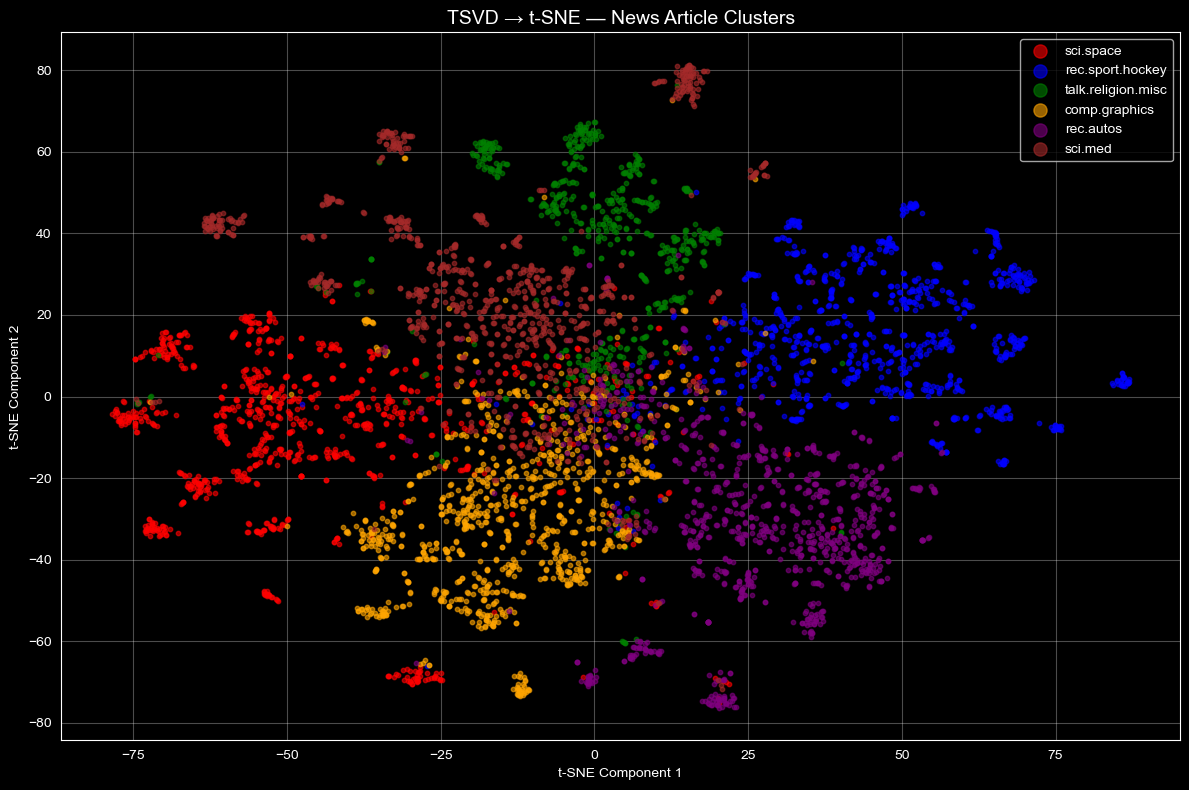

In [29]:
# t-SNE on TSVD output (much better for text visualization!)
# Warning: takes 2-3 minutes to run!
print("Running t-SNE... please wait ⏳")

tsne = TSNE(n_components=2,
            random_state=42,
            perplexity=30,
            max_iter=1000)

X_tsne = tsne.fit_transform(X_tsvd_subset)

print("Done! ✅")

# Plot
plt.figure(figsize=(12, 8))

for i, category in enumerate(selected_categories):
    mask_cat = df_subset['category'] == category
    plt.scatter(
        X_tsne[mask_cat, 0],
        X_tsne[mask_cat, 1],
        c=colors[i],
        label=category,
        alpha=0.6,
        s=10
    )

plt.title("TSVD → t-SNE — News Article Clusters", fontsize=14)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(markerscale=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
# Use full dataset for classification (all 20 categories)
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_tsvd_subset,
    y_subset,
    test_size=0.2,
    random_state=42,
    stratify=y_subset
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (4453, 100)
Test size: (1114, 100)


In [31]:
# Apply LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Predict
y_pred_lda = lda.predict(X_test)

# Results
print("=== LDA Classification Results ===")
print(f"Accuracy: {round(accuracy_score(y_test, y_pred_lda) * 100, 2)}%")
print()
print(classification_report(y_test, y_pred_lda,
      target_names=selected_categories))

=== LDA Classification Results ===
Accuracy: 91.2%

                    precision    recall  f1-score   support

         sci.space       0.81      0.95      0.87       195
  rec.sport.hockey       0.94      0.89      0.91       198
talk.religion.misc       1.00      0.95      0.97       200
     comp.graphics       0.86      0.88      0.87       198
         rec.autos       0.96      0.90      0.93       197
           sci.med       0.95      0.90      0.92       126

          accuracy                           0.91      1114
         macro avg       0.92      0.91      0.91      1114
      weighted avg       0.92      0.91      0.91      1114



=== TECHNIQUE COMPARISON ===

TSVD + LDA  : 91.2%
TSVD + SVM  : 93.27%
NMF  + SVM  : 81.6%


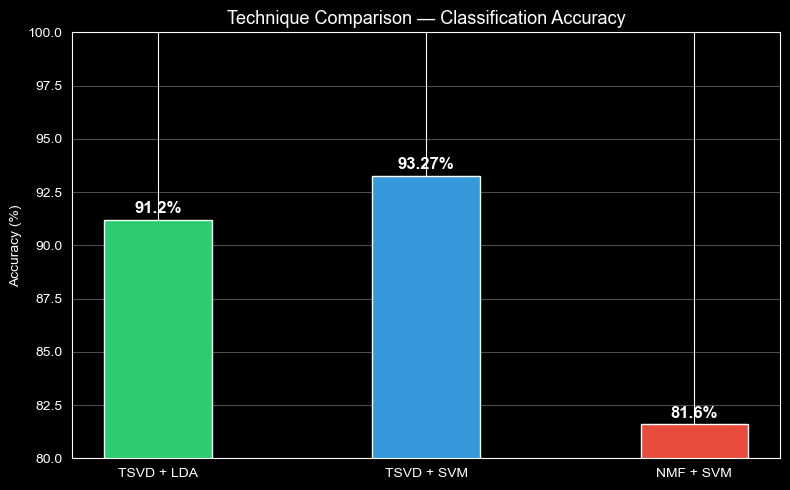

In [32]:
# Compare TSVD+LDA vs just TSVD+SVM vs NMF+SVM

# Model 1 — LDA (already done)
lda_acc = round(accuracy_score(y_test, y_pred_lda) * 100, 2)

# Model 2 — TSVD + SVM
svm = LinearSVC(random_state=42, max_iter=2000)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
svm_acc = round(accuracy_score(y_test, y_pred_svm) * 100, 2)

# Model 3 — NMF + SVM
X_nmf_subset = X_nmf[mask.values]
X_train_nmf, X_test_nmf, _, _ = train_test_split(
    X_nmf_subset, y_subset,
    test_size=0.2,
    random_state=42,
    stratify=y_subset
)
svm_nmf = LinearSVC(random_state=42, max_iter=2000)
svm_nmf.fit(X_train_nmf, y_train)
y_pred_nmf = svm_nmf.predict(X_test_nmf)
nmf_acc = round(accuracy_score(y_test, y_pred_nmf) * 100, 2)

# Print comparison
print("=== TECHNIQUE COMPARISON ===\n")
print(f"TSVD + LDA  : {lda_acc}%")
print(f"TSVD + SVM  : {svm_acc}%")
print(f"NMF  + SVM  : {nmf_acc}%")

# Bar chart
techniques = ['TSVD + LDA', 'TSVD + SVM', 'NMF + SVM']
accuracies = [lda_acc, svm_acc, nmf_acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(techniques, accuracies,
               color=['#2ecc71', '#3498db', '#e74c3c'],
               width=0.4)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{acc}%', ha='center',
             fontweight='bold', fontsize=12)

plt.title("Technique Comparison — Classification Accuracy",
          fontsize=13)
plt.ylabel("Accuracy (%)")
plt.ylim(80, 100)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [33]:
# Full dataset - all 20 categories
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_tsvd, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

svm_full = LinearSVC(random_state=42, max_iter=2000)
svm_full.fit(X_train_f, y_train_f)
y_pred_full = svm_full.predict(X_test_f)

print("Full dataset accuracy:",
      round(accuracy_score(y_test_f, y_pred_full) * 100, 2), "%")

Full dataset accuracy: 83.24 %
